# Computer Vision pour l'IA 



| Sujet| Categorie officielle | Couvert dans ce notebook |
|---|---|---|
| Convolutional Layers | Both (theorie + pratique) | Section 1 |
| Image Classification | Practice | Section 2 |
| Object Detection (YOLO, SSD, DETR) | Practice | Section 3 |
| Image Segmentation (U-Net) | Practice | Section 4 |
| Pre-trained Vision Encoders (ResNet) | Practice | Section 2 |
| Image Augmentation | Practice | Section 5 |
| Generating Images with GANs | Practice | Section 6 |
| Self-Supervised Learning for Vision | Practice | Section 7 |
| Vision-text encoders (CLIP) | Practice | Section 8 |
| Diffusion Models | Practice | Section 9 |


**Note** : les images utilisees sont **generees en synthese** (formes simples dessinees avec PIL) pour rester reproductible hors-ligne. Les modeles pre-entraines (ResNet, CLIP, detection, segmentation, diffusion) necessitent en revanche une connexion internet au premier chargement (telechargement des poids).

**A installer avant la seance** :
```bash
pip install torchvision transformers diffusers pillow
```

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image, ImageDraw

try:
    import torchvision
    from torchvision import transforms, models
    TORCHVISION_DISPONIBLE = True
except ImportError:
    TORCHVISION_DISPONIBLE = False
    print("torchvision non installe -> pip install torchvision")

try:
    from transformers import pipeline
    HF_DISPONIBLE = True
except ImportError:
    HF_DISPONIBLE = False
    print("transformers non installe -> pip install transformers")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device utilise:", device)

device utilise: cuda


### Petit generateur d'images synthetiques (utilise dans plusieurs sections)

On dessine des formes geometriques simples (cercles, carres, triangles) sur fond uni : ca donne un dataset jouet, mais suffisant pour illustrer chaque brique du pipeline sans dependre d'un telechargement.

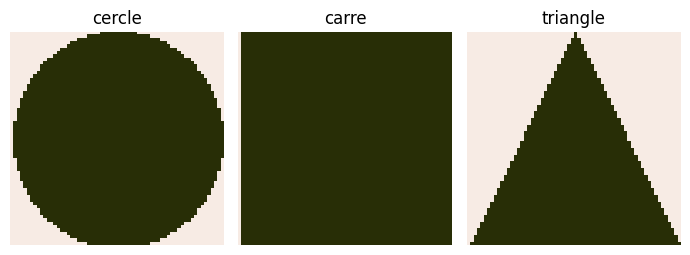

In [2]:
def generer_image_forme(forme="cercle", taille=64, seed=None):
    """Genere une image RGB avec une forme geometrique de couleur et position aleatoires."""
    rng = np.random.default_rng(seed)
    fond = tuple(rng.integers(200, 256, size=3).tolist())
    img = Image.new("RGB", (taille, taille), color=fond)
    draw = ImageDraw.Draw(img)
    couleur = tuple(rng.integers(0, 150, size=3).tolist())
    marge = taille // 4
    x0, y0 = rng.integers(0, marge, size=2).tolist()
    x1, y1 = taille - x0, taille - y0

    if forme == "cercle":
        draw.ellipse([x0, y0, x1, y1], fill=couleur)
    elif forme == "carre":
        draw.rectangle([x0, y0, x1, y1], fill=couleur)
    elif forme == "triangle":
        draw.polygon([(taille // 2, y0), (x0, y1), (x1, y1)], fill=couleur)
    return img


fig, axes = plt.subplots(1, 3, figsize=(7, 3))
for ax, forme in zip(axes, ["cercle", "carre", "triangle"]):
    ax.imshow(generer_image_forme(forme, seed=0))
    ax.set_title(forme)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 1. Convolutional Layers (fondamentaux, theorie + pratique)

Une convolution fait glisser un petit filtre (le "kernel") sur toute l'image, et calcule a chaque position une somme ponderee des pixels sous le filtre. Le reseau apprend lui-meme les valeurs de ces filtres.

**Analogie** : imagine une loupe qu'on deplace sur un tableau pointilliste. A chaque position, la loupe resume localement ce qu'elle voit (un contour, une texture) en un seul chiffre. Plusieurs loupes differentes (plusieurs filtres) tournent en parallele, chacune specialisee dans un motif different : l'une pour les contours verticaux, une autre pour une teinte particuliere, etc.

### Fiche technique : la formule de taille de sortie

Pour une dimension (largeur ou hauteur), la taille de sortie d'une convolution est :

```
taille_sortie = floor( (taille_entree - kernel_size + 2*padding) / stride ) + 1
```

| Parametre | Role | Effet |
|---|---|---|
| `kernel_size` | taille du filtre glissant | plus grand = capte des motifs plus larges, mais plus de calculs |
| `stride` | pas de deplacement du filtre | `stride=2` divise grossierement la taille par 2, comme un pooling implicite |
| `padding` | bordure de zeros ajoutee autour de l'image | `padding` bien choisi permet de garder la meme taille en sortie qu'en entree |

Le **champ receptif** (receptive field) d'un neurone, c'est la portion de l'image d'entree qui influence sa valeur : il grandit a chaque couche de convolution empilee, ce qui permet aux couches profondes de "voir" des motifs de plus en plus larges et abstraits a partir de details locaux.

In [3]:
# verification numerique de la formule de taille de sortie
conv_test = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1)
entree_test = torch.randn(1, 3, 64, 64)
sortie_test = conv_test(entree_test)
print("entree:", entree_test.shape, "-> sortie:", sortie_test.shape)
# formule : (64 - 3 + 2*1) / 1 + 1 = 64  -> meme taille, grace au padding=1 avec kernel_size=3

conv_stride2 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=2, padding=1)
sortie_stride2 = conv_stride2(entree_test)
print("avec stride=2:", sortie_stride2.shape)
# formule : (64 - 3 + 2*1) / 2 + 1 = 32.5 -> floor -> 32

entree: torch.Size([1, 3, 64, 64]) -> sortie: torch.Size([1, 8, 64, 64])
avec stride=2: torch.Size([1, 8, 32, 32])


### Visualiser ce qu'un filtre convolutif detecte (feature maps)

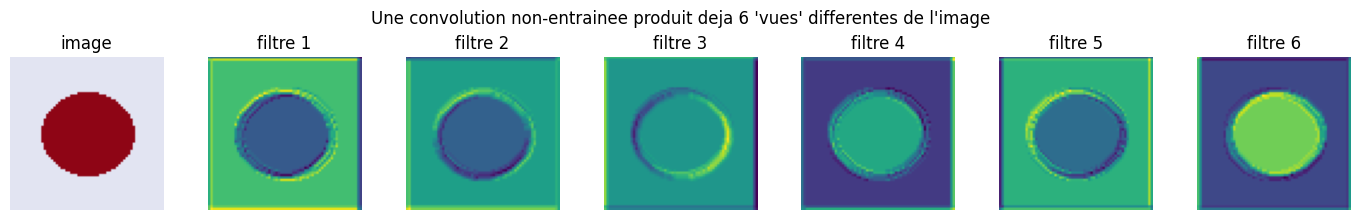

In [4]:
img_exemple = generer_image_forme("cercle", taille=64, seed=1)
tensor_image = transforms.ToTensor()(img_exemple).unsqueeze(0) if TORCHVISION_DISPONIBLE else torch.from_numpy(
    np.array(img_exemple).transpose(2, 0, 1) / 255.0
).float().unsqueeze(0)

conv_visu = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, padding=2)
with torch.no_grad():
    feature_maps = conv_visu(tensor_image)

fig, axes = plt.subplots(1, 7, figsize=(14, 2.2))
axes[0].imshow(img_exemple)
axes[0].set_title("image")
axes[0].axis("off")
for i in range(6):
    axes[i + 1].imshow(feature_maps[0, i].numpy(), cmap="viridis")
    axes[i + 1].set_title(f"filtre {i+1}")
    axes[i + 1].axis("off")
plt.suptitle("Une convolution non-entrainee produit deja 6 'vues' differentes de l'image")
plt.tight_layout()
plt.show()

## 2. Image Classification & Pre-trained Vision Encoders (ResNet)

La classification d'images "from scratch" (un petit CNN, comme dans le notebook sur le pipeline PyTorch complet) fonctionne bien sur des taches simples (MNIST). Sur des images naturelles complexes, on part presque toujours d'un **encodeur pre-entraine** comme ResNet, deja entraine sur des millions d'images (ImageNet), et on l'adapte a la tache.

**Analogie** : c'est la meme logique que pour le texte avec BERT : pourquoi reapprendre a "voir" les contours, textures et formes de base depuis zero, alors qu'un modele a deja appris ca sur des millions d'images ? On reutilise ce savoir, et on ne specialise que la derniere couche (ou quelques-unes) pour notre tache precise.

### Deux strategies de transfer learning

| Strategie | Ce qu'on fait | Quand l'utiliser |
|---|---|---|
| **Feature extraction** | on gele tout le ResNet (`requires_grad=False`), on remplace juste la derniere couche par une nouvelle tete, qu'on entraine seule | peu de donnees, tache proche d'ImageNet |
| **Fine-tuning complet** | on reentraine tout le modele (backbone + tete), avec un `lr` plus faible que pour la tete | plus de donnees disponibles, tache assez differente d'ImageNet |

In [5]:
if TORCHVISION_DISPONIBLE:
    # charger ResNet-18 pre-entraine sur ImageNet (necessite internet la 1ere fois)
    resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # strategie "feature extraction" : on gele tout le backbone
    for parametre in resnet.parameters():
        parametre.requires_grad = False

    # on remplace la derniere couche (a l'origine 1000 classes ImageNet) par notre propre tete
    nb_classes_perso = 3   # ex : cercle / carre / triangle
    resnet.fc = nn.Linear(resnet.fc.in_features, nb_classes_perso)
    # seule resnet.fc a requires_grad=True par defaut -> seule cette couche sera entrainee

    print(resnet.fc)
    print("nb de parametres entrainables:",
          sum(p.numel() for p in resnet.parameters() if p.requires_grad))
    print("nb de parametres total:", sum(p.numel() for p in resnet.parameters()))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ariel/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:15<00:00, 3.09MB/s]


Linear(in_features=512, out_features=3, bias=True)
nb de parametres entrainables: 1539
nb de parametres total: 11178051


### Fiche technique : la normalisation ImageNet : un piege frequent

Tout modele pre-entraine sur ImageNet attend des images normalisees avec des statistiques **precises** (moyenne et ecart-type calcules sur ImageNet, par canal RGB) :

```
moyenne = [0.485, 0.456, 0.406]
ecart_type = [0.229, 0.224, 0.225]
```

Nourrir ResNet avec des images non normalisees (ou normalisees differemment) ne provoque **aucune erreur** : le modele tourne quand meme : mais ses performances s'effondrent silencieusement, car les statistiques des pixels ne correspondent plus a ce qu'il a appris a l'entrainement.

In [6]:
if TORCHVISION_DISPONIBLE:
    transform_imagenet = transforms.Compose([
        transforms.Resize((224, 224)),   # ResNet attend des images 224x224
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    img_test = generer_image_forme("carre", seed=2)
    entree_normalisee = transform_imagenet(img_test).unsqueeze(0)
    resnet.eval()
    with torch.no_grad():
        logits = resnet(entree_normalisee)
    print("shape des logits:", logits.shape)   # (1, 3) -> nos 3 classes personnalisees

shape des logits: torch.Size([1, 3])


## 3. Object Detection (YOLO, SSD, DETR)

La classification dit "quoi" est dans l'image. La detection d'objets dit en plus "ou" : elle predit des **boites englobantes** (bounding boxes) et une classe pour chaque objet detecte.

| Famille | Principe | Point fort |
|---|---|---|
| **YOLO** (You Only Look Once) | decoupe l'image en grille, predit boites + classes en un seul passage | tres rapide, adapte au temps reel |
| **SSD** (Single Shot Detector) | similaire a YOLO, predictions a plusieurs echelles de la meme image | bon compromis vitesse/precision |
| **DETR** (DEtection TRansformer) | traite la detection comme un probleme de "traduction" avec un Transformer (l'image en entree, un ensemble de boites en sortie) | pas besoin de post-traitement complexe (NMS), mais plus lent a entrainer |

**Analogie** : la classification, c'est repondre "il y a un chat dans cette photo". La detection, c'est repondre "il y a un chat, il occupe ce rectangle precis de l'image, et il y a aussi un chien juste a cote, dans cet autre rectangle".

In [7]:
if TORCHVISION_DISPONIBLE:
    # torchvision fournit des modeles de detection pre-entraines directement utilisables
    detecteur = models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    detecteur.eval()

    img_test_detection = generer_image_forme("cercle", taille=224, seed=3)
    tensor_detection = transforms.ToTensor()(img_test_detection)

    with torch.no_grad():
        predictions = detecteur([tensor_detection])

    print("cles de la prediction:", predictions[0].keys())
    print("nb de boites detectees:", len(predictions[0]["boxes"]))
    # NOTE : ce detecteur est entraine sur COCO (personnes, voitures, animaux...), pas sur des
    # formes geometriques -> il ne detectera probablement rien ici, mais le pattern d'appel est le bon.
    # ('boxes' = coordonnees, 'labels' = classe predite, 'scores' = confiance)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\ariel/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:27<00:00, 6.02MB/s] 


cles de la prediction: dict_keys(['boxes', 'labels', 'scores'])
nb de boites detectees: 10


**Aller plus loin (semaine)** : pour entrainer un vrai detecteur sur ses propres donnees, il faut un dataset annote avec des boites (format COCO ou YOLO), et generalement on repart d'un modele pre-entraine (comme ci-dessus) qu'on fine-tune sur ses classes : rarement from scratch.

## 4. Image Segmentation (U-Net)

La segmentation va encore plus loin que la detection : au lieu d'une boite rectangulaire, elle predit une classe **pour chaque pixel** de l'image (ex : "ce pixel appartient au cercle", "ce pixel est le fond").

**U-Net** est l'architecture de reference pour la segmentation. Elle a une forme de "U" :
- une branche **encodeur** qui reduit progressivement la resolution spatiale (comme un CNN classique), pour capturer le contexte global
- une branche **decodeur** symetrique qui remonte en resolution, pour retrouver la precision pixel par pixel
- des **connexions residuelles ("skip connections")** entre encodeur et decodeur au meme niveau de resolution, qui transmettent les details fins perdus pendant la compression

**Analogie** : l'encodeur, c'est prendre du recul sur un dessin pour en comprendre la structure globale (ou sont les formes) ; le decodeur, c'est se rapprocher a nouveau pour repasser les contours au feutre fin ; les skip connections, c'est garder sous la main le dessin original a cote, pour ne pas perdre les details precis pendant qu'on raisonne sur la vue d'ensemble.

In [8]:
class MiniUNet(nn.Module):
    """Version tres simplifiee d'un U-Net, pour illustrer le principe encodeur/decodeur + skip connections."""
    def __init__(self, nb_classes=2):
        super().__init__()
        # encodeur
        self.enc1 = nn.Sequential(nn.Conv2d(3, 16, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)

        # goulot d'etranglement (le point le plus "compresse")
        self.bottleneck = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU())

        # decodeur
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(64, 32, 3, padding=1), nn.ReLU())  # 64 = 32(up) + 32(skip)
        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(32, 16, 3, padding=1), nn.ReLU())  # 32 = 16(up) + 16(skip)

        self.sortie = nn.Conv2d(16, nb_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)                    # taille pleine
        e2 = self.enc2(self.pool1(e1))        # taille / 2
        b = self.bottleneck(self.pool2(e2))   # taille / 4

        d2 = self.up2(b)                                  # remonte a taille / 2
        d2 = self.dec2(torch.cat([d2, e2], dim=1))         # skip connection avec e2
        d1 = self.up1(d2)                                 # remonte a taille pleine
        d1 = self.dec1(torch.cat([d1, e1], dim=1))         # skip connection avec e1

        return self.sortie(d1)


unet_test = MiniUNet(nb_classes=2)
entree_unet = torch.randn(1, 3, 64, 64)
sortie_unet = unet_test(entree_unet)
print("shape de sortie (masque de segmentation):", sortie_unet.shape)
# (1, 2, 64, 64) : pour chaque pixel, un score par classe (ici 2 classes : fond / forme)

shape de sortie (masque de segmentation): torch.Size([1, 2, 64, 64])


In [9]:
if TORCHVISION_DISPONIBLE:
    # pour un vrai projet, on part generalement d'un modele de segmentation pre-entraine
    modele_seg_pretrained = models.segmentation.deeplabv3_resnet50(weights="DEFAULT")
    modele_seg_pretrained.eval()

    img_test_seg = generer_image_forme("carre", taille=224, seed=4)
    entree_seg = transform_imagenet(img_test_seg).unsqueeze(0)
    with torch.no_grad():
        sortie_seg = modele_seg_pretrained(entree_seg)["out"]
    print("shape de sortie DeepLabV3:", sortie_seg.shape)  # (1, 21, 224, 224) : 21 classes de Pascal VOC

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\ariel/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth
100%|██████████| 161M/161M [00:41<00:00, 4.05MB/s] 


shape de sortie DeepLabV3: torch.Size([1, 21, 224, 224])


## 5. Image Augmentation

Multiplier artificiellement la diversite des donnees d'entrainement en appliquant des transformations qui preservent le contenu semantique de l'image (un chat retourne horizontalement reste un chat).

**Analogie** : c'est comme faire reviser un eleve sur le meme exercice mais presente sous des angles differents (texte agrandi, en italique, en couleur inversee) : il apprend a reconnaitre le concept, pas juste la mise en page exacte d'un seul exemple.

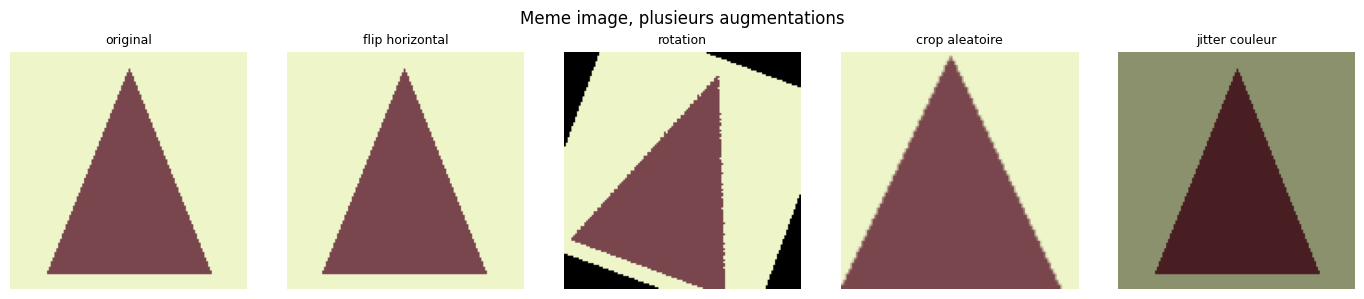

In [10]:
if TORCHVISION_DISPONIBLE:
    img_original = generer_image_forme("triangle", taille=128, seed=5)

    augmentations = {
        "original": transforms.Compose([]),
        "flip horizontal": transforms.RandomHorizontalFlip(p=1.0),
        "rotation": transforms.RandomRotation(degrees=30),
        "crop aleatoire": transforms.RandomResizedCrop(128, scale=(0.6, 1.0)),
        "jitter couleur": transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    }

    fig, axes = plt.subplots(1, len(augmentations), figsize=(14, 3))
    for ax, (nom, transform) in zip(axes, augmentations.items()):
        ax.imshow(transform(img_original))
        ax.set_title(nom, fontsize=9)
        ax.axis("off")
    plt.suptitle("Meme image, plusieurs augmentations")
    plt.tight_layout()
    plt.show()

### Fiche technique : ou s'arreter avec l'augmentation ?

Toutes les augmentations ne sont pas valides pour toutes les taches : retourner horizontalement un panneau routier avec du texte inverserait le texte (invalide) ; retourner verticalement une photo de visage n'a pas de sens (les visages ne sont jamais a l'envers en pratique). Le bon reflexe : se demander "cette transformation correspond-elle a une variation realiste que le modele pourrait rencontrer en usage reel ?"

Techniques plus avancees a connaitre (mentionnees dans le syllabus via "Data Processing") : **Mixup** (mélanger deux images et leurs labels proportionnellement) et **CutMix** (coller un patch d'une image sur une autre, en melangeant les labels proportionnellement a la surface).

## 6. Generating Images with GANs

Un **GAN** (Generative Adversarial Network) oppose deux reseaux :
- le **generateur** : part de bruit aleatoire et essaie de produire une image realiste
- le **discriminateur** : essaie de distinguer les vraies images (du dataset) des fausses (produites par le generateur)

Les deux s'entrainent simultanement, en s'ameliorant l'un l'autre : le generateur devient meilleur pour tromper le discriminateur, qui devient meilleur pour le demasquer.

**Analogie** : c'est un faussaire (generateur) et un expert en authentification d'art (discriminateur) qui s'entrainent l'un contre l'autre. A force de tromper l'expert, le faussaire devient de plus en plus doue ; a force d'etre trompe, l'expert devient de plus en plus pointu. A la fin (en theorie), le faussaire produit des faux quasiment indiscernables des vrais.

In [11]:
class GenerateurSimple(nn.Module):
    def __init__(self, dim_bruit=32, taille_image=32):
        super().__init__()
        self.taille_image = taille_image
        self.reseau = nn.Sequential(
            nn.Linear(dim_bruit, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 3 * taille_image * taille_image), nn.Tanh(),   # Tanh -> pixels dans [-1, 1]
        )

    def forward(self, bruit):
        sortie = self.reseau(bruit)
        return sortie.view(-1, 3, self.taille_image, self.taille_image)


class DiscriminateurSimple(nn.Module):
    def __init__(self, taille_image=32):
        super().__init__()
        self.reseau = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * taille_image * taille_image, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1),   # 1 logit : vrai (grand) ou faux (petit)
        )

    def forward(self, image):
        return self.reseau(image)


generateur = GenerateurSimple()
discriminateur = DiscriminateurSimple()

bruit_test = torch.randn(4, 32)
image_generee = generateur(bruit_test)
print("shape des images generees:", image_generee.shape)
print("prediction du discriminateur (logits):", discriminateur(image_generee).squeeze())

shape des images generees: torch.Size([4, 3, 32, 32])
prediction du discriminateur (logits): tensor([-0.0147, -0.0156, -0.0160, -0.0184], grad_fn=<SqueezeBackward0>)


### Squelette de boucle d'entrainement d'un GAN

On alterne : une etape pour ameliorer le discriminateur, une etape pour ameliorer le generateur. Pas de veritable entrainement complet ici (il faudrait un vrai dataset et beaucoup d'epochs) : l'objectif est de comprendre la mecanique en 2 temps.

In [12]:
fonction_loss_gan = nn.BCEWithLogitsLoss()
optim_generateur = optim.Adam(generateur.parameters(), lr=2e-4)
optim_discriminateur = optim.Adam(discriminateur.parameters(), lr=2e-4)

# un "vrai" batch d'exemple, genere en synthese pour la demo (en pratique : vraies images du dataset)
vraies_images = torch.stack([
    transforms.ToTensor()(generer_image_forme("cercle", taille=32, seed=i)) * 2 - 1  # -> [-1, 1] comme Tanh
    for i in range(8)
]) if TORCHVISION_DISPONIBLE else torch.randn(8, 3, 32, 32)

taille_batch = vraies_images.size(0)
labels_vrais = torch.ones(taille_batch, 1)
labels_faux = torch.zeros(taille_batch, 1)

# --- etape 1 : entrainer le discriminateur ---
optim_discriminateur.zero_grad()
perte_vrais = fonction_loss_gan(discriminateur(vraies_images), labels_vrais)

bruit = torch.randn(taille_batch, 32)
fausses_images = generateur(bruit).detach()   # .detach() : on ne veut pas entrainer le generateur ici
perte_faux = fonction_loss_gan(discriminateur(fausses_images), labels_faux)

perte_discriminateur = perte_vrais + perte_faux
perte_discriminateur.backward()
optim_discriminateur.step()

# --- etape 2 : entrainer le generateur ---
optim_generateur.zero_grad()
bruit = torch.randn(taille_batch, 32)
fausses_images = generateur(bruit)
# le generateur "gagne" si le discriminateur les classe comme vraies -> on compare a labels_vrais
perte_generateur = fonction_loss_gan(discriminateur(fausses_images), labels_vrais)
perte_generateur.backward()
optim_generateur.step()

print(f"perte discriminateur: {perte_discriminateur.item():.4f} | perte generateur: {perte_generateur.item():.4f}")

perte discriminateur: 1.4116 | perte generateur: 0.7082


**Piege classique des GANs** : le "mode collapse" : le generateur trouve une seule image (ou tres peu de variations) qui trompe systematiquement le discriminateur, et arrete d'explorer d'autres possibilites. Symptome : toutes les images generees se ressemblent, quel que soit le bruit d'entree. C'est l'une des raisons pour lesquelles les GANs sont aujourd'hui souvent remplaces par des modeles de diffusion (section 9) pour la generation d'images de haute qualite.

## 7. Self-Supervised Learning for Vision

Le self-supervised learning apprend des representations utiles **sans aucun label humain**, en inventant une tache "pretexte" ou l'etiquette peut etre generee automatiquement a partir des donnees elles-memes.

**Analogie** : c'est comme apprendre a un enfant a comprendre une scene en lui demandant de remettre les pieces d'un puzzle dans le bon ordre : il n'a besoin d'aucune legende ecrite par un adulte, la solution est deja contenue dans les donnees elles-memes (l'image originale, avant d'etre decoupee).

### Exemple de tache pretexte : prediction de rotation

On fait tourner chaque image de 0, 90, 180 ou 270 degres, et on entraine un modele a deviner l'angle applique. Pour bien reussir, le modele doit apprendre a reconnaitre l'orientation "naturelle" des objets : ce qui, au passage, lui fait apprendre des representations visuelles utiles (formes, contours, orientation), reutilisables ensuite pour la vraie tache (fine-tuning sur un petit jeu de donnees labellise, comme en section 2).

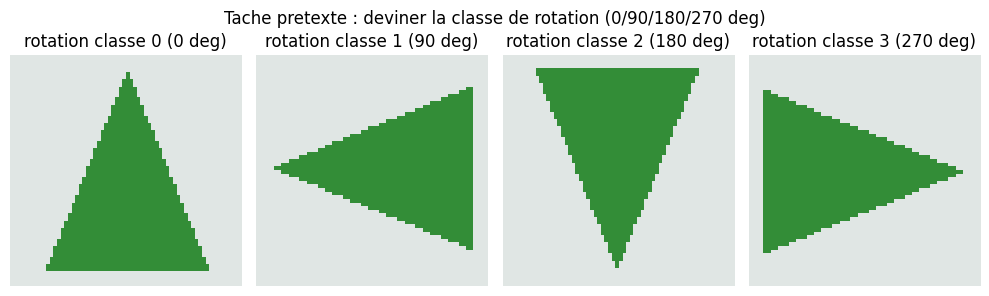

shape de la prediction (4 classes d'angle): torch.Size([1, 4])


In [13]:
def appliquer_rotation_aleatoire(image_tensor):
    """Fait tourner une image de 0/90/180/270 degres et retourne (image tournee, classe de rotation)."""
    angle_idx = torch.randint(0, 4, (1,)).item()   # 0->0deg, 1->90deg, 2->180deg, 3->270deg
    image_tournee = torch.rot90(image_tensor, k=angle_idx, dims=[1, 2])
    return image_tournee, angle_idx


img_test_rot = transforms.ToTensor()(generer_image_forme("triangle", seed=6)) if TORCHVISION_DISPONIBLE \
    else torch.rand(3, 64, 64)

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for k in range(4):
    img_rot = torch.rot90(img_test_rot, k=k, dims=[1, 2])
    axes[k].imshow(img_rot.permute(1, 2, 0))
    axes[k].set_title(f"rotation classe {k} ({k*90} deg)")
    axes[k].axis("off")
plt.suptitle("Tache pretexte : deviner la classe de rotation (0/90/180/270 deg)")
plt.tight_layout()
plt.show()

# un encodeur convolutif + une petite tete de classification a 4 classes (une par angle) suffit :
encodeur_ssl = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((4, 4)),
)
tete_rotation = nn.Linear(32 * 4 * 4, 4)   # 4 classes de rotation

image_batch, angle_batch = appliquer_rotation_aleatoire(img_test_rot)
representation = encodeur_ssl(image_batch.unsqueeze(0)).flatten(1)
prediction_angle = tete_rotation(representation)
print("shape de la prediction (4 classes d'angle):", prediction_angle.shape)
# une fois entraine sur cette tache pretexte, on jetterait 'tete_rotation'
# et on reutiliserait 'encodeur_ssl' comme point de depart pour la vraie tache

## 8. Vision-text encoders (CLIP)

**CLIP** (Contrastive Language-Image Pre-training) apprend conjointement un encodeur d'images et un encodeur de texte, de sorte que l'embedding d'une image et l'embedding de sa legende textuelle soient **proches** dans le meme espace vectoriel : et que ceux d'une image et d'une legende qui ne correspondent pas soient **eloignes**.

**Analogie** : imagine un traducteur simultane qui, au lieu de traduire mot a mot, place chaque image et chaque phrase sur une meme carte commune, ou les points proches se "comprennent" mutuellement : une photo de chat et le texte "a photo of a cat" atterrissent au meme endroit sur cette carte, meme si l'un est un pixel et l'autre du texte.

Consequence tres utile : la **classification zero-shot** : on peut classifier une image sur des categories qui n'ont **jamais ete vues a l'entrainement**, juste en comparant l'embedding de l'image aux embeddings de plusieurs descriptions textuelles candidates, et en choisissant la plus proche.

In [14]:
if HF_DISPONIBLE:
    from transformers import CLIPModel, CLIPProcessor

    nom_modele_clip = "openai/clip-vit-base-patch32"
    modele_clip = CLIPModel.from_pretrained(nom_modele_clip)
    processeur_clip = CLIPProcessor.from_pretrained(nom_modele_clip)

    image_a_classer = generer_image_forme("cercle", taille=224, seed=7)
    descriptions_candidates = ["a photo of a circle", "a photo of a square", "a photo of a triangle"]

    entrees = processeur_clip(text=descriptions_candidates, images=image_a_classer,
                                return_tensors="pt", padding=True)
    with torch.no_grad():
        sorties = modele_clip(**entrees)
        scores = sorties.logits_per_image.softmax(dim=1)   # probabilite pour chaque description

    for description, score in zip(descriptions_candidates, scores[0]):
        print(f"{description}: {score.item():.2%}")
    # CLIP n'a jamais ete entraine specifiquement sur des formes geometriques generees comme ici,
    # mais il a de bonnes chances de reconnaitre 'circle' vs 'square' vs 'triangle' grace
    # a son entrainement massif sur des images + legendes du web

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

ValueError: Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434

## 9. Diffusion Models

Les modeles de diffusion generent des images en apprenant a **inverser un processus de bruitage progressif**.

1. **Processus direct (forward)** : on part d'une vraie image, et on lui ajoute du bruit gaussien par petites etapes successives, jusqu'a obtenir du bruit pur.
2. **Processus inverse (reverse)** : un reseau de neurones apprend a predire, a chaque etape, le bruit qui a ete ajoute : ce qui lui permet, une fois entraine, de partir de bruit pur et de le "denoiser" pas a pas jusqu'a obtenir une image nette.

**Analogie** : c'est comme apprendre a un restaurateur d'art a partir de photos progressivement recouvertes de rayures et de taches (le bruitage), jusqu'a devenir illisibles. En observant des milliers de paires (image nette, meme image degradee a differents niveaux), le restaurateur apprend a "deviner" ce qui a ete efface a chaque etape : et peut donc, en partant d'une photo entierement degradee (du bruit pur), la restaurer petit a petit jusqu'a une image plausible.

Par rapport aux GANs (section 6), les modeles de diffusion sont plus stables a entrainer (pas de "combat" adversarial, donc moins de mode collapse) mais plus lents a generer (plusieurs dizaines d'etapes de denoising necessaires par image).

In [ ]:
try:
    from diffusers import StableDiffusionPipeline
    DIFFUSERS_DISPONIBLE = True
except ImportError:
    DIFFUSERS_DISPONIBLE = False
    print("diffusers non installe -> pip install diffusers")

if DIFFUSERS_DISPONIBLE:
    # ATTENTION : necessite un GPU et un telechargement de plusieurs Go la 1ere fois.
    # A executer uniquement si le materiel de la salle le permet (sinon, sauter cette cellule).
    pipeline_diffusion = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
    ).to(device)

    image_generee_diffusion = pipeline_diffusion(
        "a simple red circle on a white background, minimalist"
    ).images[0]
    plt.imshow(image_generee_diffusion)
    plt.axis("off")
    plt.title("Image generee par diffusion")
    plt.show()

In [ ]:
# demonstration conceptuelle du bruitage progressif (le processus 'forward'), sans reseau entraine
def bruiter_progressivement(image_tensor, nb_etapes=5):
    images_bruitees = [image_tensor]
    image_courante = image_tensor.clone()
    for etape in range(nb_etapes):
        niveau_bruit = (etape + 1) / nb_etapes
        bruit = torch.randn_like(image_courante)
        # interpolation simple entre image et bruit pur (les vrais schedulers de diffusion
        # utilisent des formules plus precises, mais l'intuition est la meme)
        image_courante = (1 - niveau_bruit) ** 0.5 * image_tensor + niveau_bruit ** 0.5 * bruit
        images_bruitees.append(image_courante)
    return images_bruitees


img_pour_diffusion = transforms.ToTensor()(generer_image_forme("carre", seed=8)) if TORCHVISION_DISPONIBLE \
    else torch.rand(3, 64, 64)
etapes_bruitees = bruiter_progressivement(img_pour_diffusion, nb_etapes=5)

fig, axes = plt.subplots(1, len(etapes_bruitees), figsize=(14, 2.5))
for i, (ax, img) in enumerate(zip(axes, etapes_bruitees)):
    ax.imshow(img.clamp(0, 1).permute(1, 2, 0))
    ax.set_title("originale" if i == 0 else f"etape {i}")
    ax.axis("off")
plt.suptitle("Processus forward simplifie : bruitage progressif jusqu'a un bruit quasi pur")
plt.tight_layout()
plt.show()

## 10. Bonnes pratiques specifiques a la vision

### 10.1 Coherence de la normalisation
Toujours normaliser exactement avec les memes statistiques (moyenne/ecart-type) a l'entrainement ET a l'inference. Si on utilise un encodeur pre-entraine, utiliser ses statistiques a lui, pas des valeurs generiques.

### 10.2 `.eval()` avant toute inference
Comme pour l'audio et le texte : BatchNorm et Dropout se comportent differemment en `.train()` et en `.eval()`. Oublier `.eval()` donne des resultats instables et non reproductibles a l'inference.

### 10.3 Fuite de donnees via l'augmentation
L'augmentation de donnees (section 5) doit s'appliquer **uniquement** sur le jeu d'entrainement. L'appliquer aussi sur la validation/test fausse l'evaluation (le modele est teste sur une version artificiellement modifiee de la realite, pas sur des donnees representatives de l'usage reel).

### 10.4 Redimensionnement et ratio d'aspect
Redimensionner une image rectangulaire vers un carre (ex: 224x224) sans precaution peut deformer les objets (un cercle devient une ellipse). Selon la tache, preferer un `resize` qui preserve le ratio + un `padding`/`crop`, plutot qu'un etirement brutal.

### 10.5 Fuite de donnees par doublons ou quasi-doublons
Verifier qu'aucune image (ou quasi-duplicata : meme photo recadree, meme scene sous un angle legerement different) ne se retrouve a la fois dans le train et dans le test : frequent avec des donnees collectees en rafale (plusieurs photos de la meme scene).

## 11. Section debug : bugs specifiques a la vision

Meme methode que les notebooks precedents : chaque cellule contient un bug volontaire.

### Bug CV 1 : normalisation incoherente avec un modele pre-entraine

In [ ]:
# BUG CV 1 (a corriger)
if TORCHVISION_DISPONIBLE:
    resnet_bug = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    resnet_bug.eval()

    transform_bug = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        # <- aucune normalisation ImageNet ici !
    ])

    img_bug1 = generer_image_forme("cercle", seed=9)
    entree_bug1 = transform_bug(img_bug1).unsqueeze(0)
    with torch.no_grad():
        sortie_bug1 = resnet_bug(entree_bug1)
    print("shape:", sortie_bug1.shape, "-> le code tourne, mais les predictions seront peu fiables")
    # indice : relis la fiche technique de la section 2 sur la normalisation ImageNet

*Corrige le bug ici :*

In [ ]:
# ta version corrigee



### Bug CV 2 : mode `.eval()` oublie

In [ ]:
# BUG CV 2 (a corriger)
if TORCHVISION_DISPONIBLE:
    modele_bug2 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # PAS de modele_bug2.eval() ici !

    entree_bug2 = torch.randn(1, 3, 224, 224)
    with torch.no_grad():
        sortie1 = modele_bug2(entree_bug2)
        sortie2 = modele_bug2(entree_bug2)
    print("les deux sorties sont identiques ?", torch.allclose(sortie1, sortie2))
    # indice : BatchNorm utilise des statistiques de batch en mode train, pas en mode eval

*Corrige le bug ici :*

In [ ]:
# ta version corrigee



### Bug CV 3 : ecrasement des dimensions (channels-first vs channels-last)

In [ ]:
# BUG CV 3 (a corriger)
img_bug3 = generer_image_forme("triangle", taille=64, seed=10)
tableau_numpy = np.array(img_bug3)   # shape (64, 64, 3) -> hauteur, largeur, canaux (channels-last)
print("shape numpy:", tableau_numpy.shape)

tensor_bug3 = torch.from_numpy(tableau_numpy).float().unsqueeze(0)   # <- pas de permutation !
conv_bug3 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1)
sortie_bug3 = conv_bug3(tensor_bug3)   # erreur : Conv2d attend (batch, canaux, hauteur, largeur)
print(sortie_bug3.shape)
# indice : PyTorch attend le format 'channels-first' (canaux juste apres le batch),
# alors que numpy/PIL donnent du 'channels-last' -> il faut permuter les dimensions

*Corrige le bug ici :*

In [ ]:
# ta version corrigee



## 12. Exercices finaux

**Exercice A : Coin Counting Machine (30-40 min)**, inspire de l'Olympiade Polonaise d'IA 2025
Genere un dataset d'images synthetiques contenant un **nombre variable** de cercles (1 a 5, positions aleatoires, en reutilisant `generer_image_forme` comme base : a adapter pour dessiner plusieurs formes sur la meme image). Entraine un petit CNN a **compter** le nombre de cercles (regression ou classification a 5 classes). Affiche la precision finale et quelques exemples avec prediction vs verite.

**Exercice B : Real or Fake Image (20-30 min)**, inspire de la finale NOAI Chine 2024
Genere deux categories d'images : des images "propres" (formes nettes, comme d'habitude) et des images "generees" simulees en ajoutant des artefacts synthetiques (bruit gaussien fort, flou gaussien, ou legere distorsion de couleur). Entraine un classifieur binaire "propre" vs "artefacts", et discute : quels indices visuels le modele a-t-il probablement appris a reperer ?

**Exercice C : multi-label classification (15-20 min)**, inspire de la 3e Olympiade Polonaise d'IA 2026
Genere des images contenant **2 formes simultanement** (par exemple un cercle ET un carre sur la meme image, a des positions differentes). Adapte la derniere couche du modele et la loss (`nn.BCEWithLogitsLoss` avec un vecteur de labels multi-hot, plutot que `nn.CrossEntropyLoss`) pour predire l'ensemble des formes presentes, pas une seule classe exclusive.

**Exercice D : chrono, image restoration (25-30 min, sans aide)**, inspire de la selection Kazakhstan (Team Selection Test)
Genere des paires (image nette, meme image degradee : flou gaussien + bruit). Construis un petit auto-encodeur convolutif (encodeur-decodeur, comme le MiniUNet de la section 4 mais plus simple, sans skip connections) qui prend l'image degradee en entree et essaie de reconstruire l'image nette. Utilise `nn.MSELoss` entre l'image reconstruite et l'image nette originale.

In [ ]:
# Exercice D : ta solution ici



